# RC1 — Data Quality & Bar Analysis

**Research Checkpoint 1** for the RSPCP Bachelor's Thesis.

This notebook validates data quality after Phases 1–2 (OHLCV ingestion + Lopez de Prado alternative bars) and makes go/no-go decisions before feature engineering (Phase 4).

**Sections:**
1. Data Coverage — heatmap, gap detection, asset filtering
2. Bar Construction — bar counts, duration statistics
3. Return Distributions — descriptive stats, QQ plots, normality tests
4. Autocorrelation — ACF/PACF, Ljung-Box, volatility clustering
5. Conclusions — summary table and go/no-go decisions

In [1]:
# Standard library
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

# Ensure we run from the project root so that:
#   1) `src.*` imports resolve correctly
#   2) .env is found by pydantic-settings (DUCKDB_PATH may be relative)
_PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
os.chdir(_PROJECT_ROOT)
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Third-party
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from bokeh.io import output_notebook, show
from bokeh.layouts import column

output_notebook()
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.6f}".format)
print(f"Working directory: {Path.cwd()}")

Loading BokehJS ...

Working directory: /home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis


In [2]:
# Project imports — analysis services
from src.app.research.application.autocorrelation_analyzer import AutocorrelationAnalyzer
from src.app.research.application.bar_comparator import BarComparator
from src.app.research.application.coverage_analyzer import CoverageAnalyzer
from src.app.research.application.data_loader import DataLoader
from src.app.research.application.return_analyzer import ReturnAnalyzer

# Project imports — chart functions
from src.app.research.infrastructure.bokeh_charts import (
    create_bar_count_histogram,
    create_coverage_heatmap,
    create_gap_timeline,
    create_statistics_table,
    create_volume_profile,
)
from src.app.research.infrastructure.matplotlib_charts import (
    create_acf_comparison_grid,
    create_acf_stem_plot,
    create_bar_duration_boxplot,
    create_qq_grid,
    create_return_distribution,
)

# Project imports — infrastructure
from src.app.system.database.connection import ConnectionManager

In [3]:
# Initialise database connection and all analysis services
cm = ConnectionManager()
cm.initialize()

loader = DataLoader(cm)
coverage_analyzer = CoverageAnalyzer(loader)
return_analyzer = ReturnAnalyzer()
acf_analyzer = AutocorrelationAnalyzer()
bar_comparator = BarComparator()

print("Services initialised successfully.")

2026-03-30 00:08:54.287 | INFO     | src.app.system.database.connection:initialize:77 - Creating DuckDB engine (path=/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/data/market.duckdb)
2026-03-30 00:08:54.542 | INFO     | src.app.system.database.connection:initialize:86 - DuckDB connection verified successfully


Services initialised successfully.


## 1. Data Coverage

Check which assets and timeframes are available, compute coverage percentages, detect gaps, and filter assets that meet minimum quality requirements.

In [4]:
# Discover available assets and timeframes
assets = loader.get_available_assets()
timeframes = ["1h", "4h", "1d"]

print(f"Available assets ({len(assets)}): {assets}")
print(f"Timeframes to analyse: {timeframes}")

Available assets (4): ['BTCUSDT', 'ETHUSDT', 'LTCUSDT', 'SOLUSDT']
Timeframes to analyse: ['1h', '4h', '1d']


In [5]:
# Compute coverage for all (asset, timeframe) pairs
coverage_records = coverage_analyzer.compute_coverage(assets, timeframes)
coverage_df = pd.DataFrame([r.model_dump() for r in coverage_records])
coverage_df

,asset,timeframe,total_bars,start_date,end_date,expected_bars,coverage_pct,gap_count
0,BTCUSDT,1h,54278,2020-01-01 00:00:00+00:00,2026-03-12 21:00:00+00:00,54310,99.941079,5
1,BTCUSDT,4h,13577,2020-01-01 00:00:00+00:00,2026-03-12 20:00:00+00:00,13578,99.992635,0
2,BTCUSDT,1d,2263,2020-01-01 00:00:00+00:00,2026-03-12 00:00:00+00:00,2263,100.000000,0
3,ETHUSDT,1h,54278,2020-01-01 00:00:00+00:00,2026-03-12 21:00:00+00:00,54310,99.941079,5
4,ETHUSDT,4h,13577,2020-01-01 00:00:00+00:00,2026-03-12 20:00:00+00:00,13578,99.992635,0
5,ETHUSDT,1d,2263,2020-01-01 00:00:00+00:00,2026-03-12 00:00:00+00:00,2263,100.000000,0
6,LTCUSDT,1h,54278,2020-01-01 00:00:00+00:00,2026-03-12 21:00:00+00:00,54310,99.941079,5
7,LTCUSDT,4h,13577,2020-01-01 00:00:00+00:00,2026-03-12 20:00:00+00:00,13578,99.992635,0
8,LTCUSDT,1d,2263,2020-01-01 00:00:00+00:00,2026-03-12 00:00:00+00:00,2263,100.000000,0
9,SOLUSDT,1h,48932,2020-08-11 06:00:00+00:00,2026-03-12 21:00:00+00:00,48952,99.959144,3


In [6]:
# Coverage heatmap (interactive Bokeh)
coverage_matrix = coverage_analyzer.build_coverage_matrix(coverage_records)
heatmap = create_coverage_heatmap(coverage_matrix)
show(heatmap)

In [7]:
# Gap detection — find significant data gaps for each asset (1h timeframe)
all_gaps = []
for asset in assets:
    gaps = coverage_analyzer.detect_gaps(asset, "1h")
    all_gaps.extend(gaps)

print(f"Total gaps detected across all assets: {len(all_gaps)}")
if all_gaps:
    gap_df = pd.DataFrame([g.model_dump() for g in all_gaps])
    display(gap_df.head(20))

Total gaps detected across all assets: 18


,asset,timeframe,gap_start,gap_end,gap_duration_hours,missing_bars
0,BTCUSDT,1h,2020-02-19 11:00:00+00:00,2020-02-19 17:00:00+00:00,6.000000,5
1,BTCUSDT,1h,2020-06-28 01:00:00+00:00,2020-06-28 05:00:00+00:00,4.000000,3
2,BTCUSDT,1h,2020-12-21 13:00:00+00:00,2020-12-21 18:00:00+00:00,5.000000,4
3,BTCUSDT,1h,2021-04-25 04:00:00+00:00,2021-04-25 08:00:00+00:00,4.000000,3
4,BTCUSDT,1h,2021-08-13 01:00:00+00:00,2021-08-13 06:00:00+00:00,5.000000,4
5,ETHUSDT,1h,2020-02-19 11:00:00+00:00,2020-02-19 17:00:00+00:00,6.000000,5
6,ETHUSDT,1h,2020-06-28 01:00:00+00:00,2020-06-28 05:00:00+00:00,4.000000,3
7,ETHUSDT,1h,2020-12-21 13:00:00+00:00,2020-12-21 18:00:00+00:00,5.000000,4
8,ETHUSDT,1h,2021-04-25 04:00:00+00:00,2021-04-25 08:00:00+00:00,4.000000,3
9,ETHUSDT,1h,2021-08-13 01:00:00+00:00,2021-08-13 06:00:00+00:00,5.000000,4


In [8]:
# Gap timeline visualisation (interactive Bokeh)
if all_gaps:
    gap_timeline = create_gap_timeline(all_gaps)
    show(gap_timeline)
else:
    print("No gaps detected — all data is continuous.")

In [9]:
# Volume profile for the first asset (interactive Bokeh — pan/zoom enabled)
if assets:
    sample_asset = assets[0]
    ohlcv_df = loader.load_ohlcv(sample_asset, "1h")
    print(f"Volume profile for {sample_asset} (1h) — {len(ohlcv_df)} candles")
    vol_fig = create_volume_profile(ohlcv_df)
    show(vol_fig)

Volume profile for BTCUSDT (1h) — 54278 candles


/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/bokeh/util/serialization.py:247: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


In [10]:
# Asset filtering — keep assets with >= 730 days of data and <= 5% gap ratio
filter_results = coverage_analyzer.filter_assets(assets, "1h", min_days=730, max_gap_ratio=0.05)
filter_df = pd.DataFrame([r.model_dump() for r in filter_results])
display(filter_df)

selected_assets = [r.asset for r in filter_results if r.included]
print(f"\nSelected assets for further analysis ({len(selected_assets)}): {selected_assets}")

,asset,included,reason,total_days,coverage_pct
0,BTCUSDT,True,Passed all quality filters,2262.875000,99.941079
1,ETHUSDT,True,Passed all quality filters,2262.875000,99.941079
2,LTCUSDT,True,Passed all quality filters,2262.875000,99.941079
3,SOLUSDT,True,Passed all quality filters,2039.625000,99.959144



Selected assets for further analysis (4): ['BTCUSDT', 'ETHUSDT', 'LTCUSDT', 'SOLUSDT']


## 2. Bar Construction

Load aggregated bars (tick, volume, dollar, imbalance, run) for selected assets, compare bar counts per week, and analyse bar duration variability across bar types.

In [11]:
# Load all available bar configurations for the first selected asset
analysis_asset = selected_assets[0] if selected_assets else assets[0]
bar_configs = loader.get_available_bar_configs(analysis_asset)
print(f"Bar configurations for {analysis_asset}: {len(bar_configs)}")
for bt, ch in bar_configs:
    print(f"  {bt} (config_hash={ch})")

# Load bar DataFrames keyed by bar_type
bar_data = {}
for bar_type, config_hash in bar_configs:
    df = loader.load_bars(analysis_asset, bar_type, config_hash)
    if not df.empty:
        bar_data[bar_type] = df
        print(f"  Loaded {bar_type}: {len(df)} bars")

print(f"\nBar types loaded: {list(bar_data.keys())}")

Bar configurations for BTCUSDT: 9
  dollar (config_hash=76c279d83686171b)
  dollar_imbalance (config_hash=225e357dea42a17c)
  dollar_run (config_hash=2931a2345ccf60d3)
  tick (config_hash=caefc807962061e2)
  tick_imbalance (config_hash=4a1b7a1a724640a6)
  tick_run (config_hash=01af1574c287ff4d)
  volume (config_hash=f01e3c219325d4ed)
  volume_imbalance (config_hash=27d360243b619bb4)
  volume_run (config_hash=09a1b00544f28793)
  Loaded dollar: 5287 bars
  Loaded dollar_imbalance: 569 bars
  Loaded dollar_run: 435 bars
  Loaded tick: 55 bars
  Loaded tick_imbalance: 2 bars
  Loaded tick_run: 1 bars
  Loaded volume: 3264 bars
  Loaded volume_imbalance: 530 bars
  Loaded volume_run: 389 bars

Bar types loaded: ['dollar', 'dollar_imbalance', 'dollar_run', 'tick', 'tick_imbalance', 'tick_run', 'volume', 'volume_imbalance', 'volume_run']


In [12]:
# Weekly bar count histogram (interactive Bokeh)
if bar_data:
    weekly_counts = {}
    for bar_type, df in bar_data.items():
        counts = bar_comparator.bar_count_per_period(df, freq="W")
        weekly_counts[bar_type] = counts

    bar_hist = create_bar_count_histogram(weekly_counts)
    show(bar_hist)

    # Compare bar count variability across types
    variability_df = bar_comparator.compare_bar_count_variability(bar_data)
    print("Bar count variability (CV = std / mean):")
    display(variability_df)
else:
    print("No bar data available — run bar aggregation first (Phase 2).")

/home/dmytro-khvedchuk/Desktop/University/Bachelors/RSPCP_bachelors_thesis/.venv/lib/python3.14/site-packages/bokeh/util/serialization.py:247: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


Bar count variability (CV = std / mean):


,bar_type,mean_count,std_count,cv
0,dollar,16.317901,11.755014,0.720375
1,dollar_imbalance,1.761610,2.951284,1.675333
2,dollar_run,1.367925,3.528144,2.579195
3,tick,0.170807,0.376926,2.206733
4,tick_imbalance,0.010582,0.102595,9.695223
5,tick_run,1.000000,0.000000,0.000000
6,volume,10.074074,10.972555,1.089187
7,volume_imbalance,1.661442,2.768554,1.666356
8,volume_run,2.301775,3.514942,1.527057


Bar duration statistics (minutes):


,asset,bar_type,mean_duration_minutes,median_duration_minutes,std_duration_minutes,min_duration_minutes,max_duration_minutes,cv
0,BTCUSDT,dollar,616.341971,420.000000,572.063469,60.000000,5520.000000,0.928159
1,BTCUSDT,dollar_imbalance,5726.889279,1740.000000,12905.186491,60.000000,179820.000000,2.253437
2,BTCUSDT,dollar_run,7491.034483,780.000000,34713.880404,60.000000,493860.000000,4.634057
3,BTCUSDT,tick,59247.272727,60000.000000,5846.717805,16680.000000,60360.000000,0.098683
4,BTCUSDT,tick_imbalance,1629300.000000,1629300.000000,382601.337164,1358760.000000,1899840.000000,0.234826
5,BTCUSDT,tick_run,3258600.000000,3258600.000000,0.000000,3258600.000000,3258600.000000,0.000000
6,BTCUSDT,volume,998.345588,660.000000,1040.131870,60.000000,7680.000000,1.041856
7,BTCUSDT,volume_imbalance,6148.301887,1500.000000,18633.567748,60.000000,205440.000000,3.030685
8,BTCUSDT,volume_run,8376.863753,1020.000000,79975.143171,60.000000,1565820.000000,9.547146


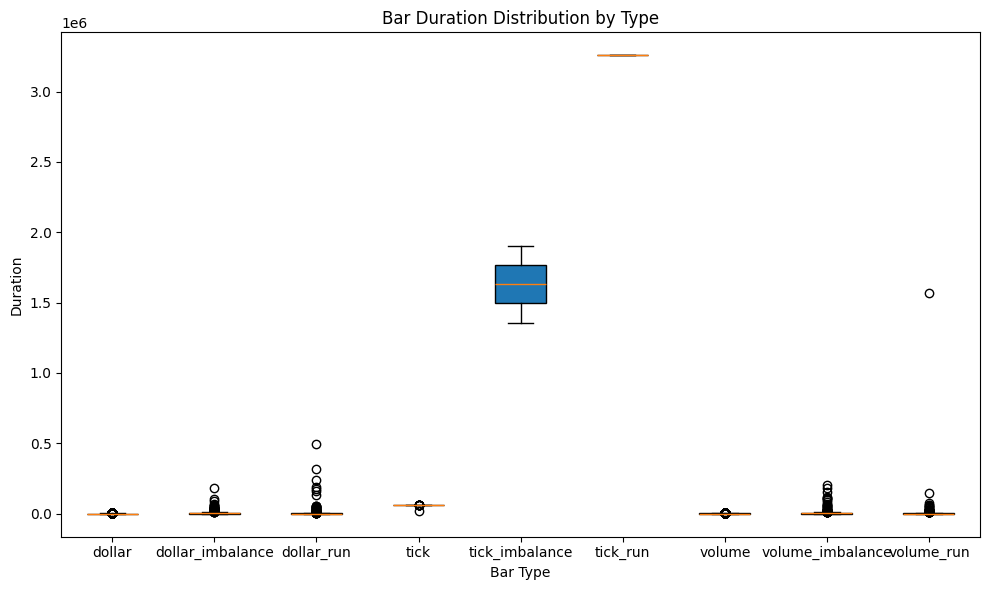

In [13]:
# Bar duration statistics and boxplot (matplotlib)
if bar_data:
    duration_stats = []
    durations_dict = {}
    for bar_type, df in bar_data.items():
        stats = bar_comparator.compute_duration_stats(df, analysis_asset, bar_type)
        duration_stats.append(stats)
        durations_dict[bar_type] = (df["end_ts"] - df["start_ts"]).dt.total_seconds() / 60.0

    dur_stats_df = pd.DataFrame([s.model_dump() for s in duration_stats])
    print("Bar duration statistics (minutes):")
    display(dur_stats_df)

    fig = create_bar_duration_boxplot(durations_dict)
    plt.show()
    plt.close(fig)

## 3. Return Distributions

Compute log returns for each bar type, test normality (Jarque-Bera), examine QQ plots, and overlay return distributions. Fat tails and non-normality are expected for crypto — the question is whether alternative bars improve distributional properties.

In [14]:
# Compute log returns per bar type
bar_returns = {}
for bar_type, df in bar_data.items():
    returns = return_analyzer.compute_log_returns(df)
    bar_returns[bar_type] = returns
    print(f"{bar_type}: {len(returns)} returns, mean={returns.mean():.6f}, std={returns.std():.6f}")

# Also compute returns from raw OHLCV (1h time bars) for comparison
ohlcv_1h = loader.load_ohlcv(analysis_asset, "1h")
if not ohlcv_1h.empty:
    time_returns = return_analyzer.compute_log_returns(ohlcv_1h)
    bar_returns["time_1h"] = time_returns
    print(f"time_1h: {len(time_returns)} returns, mean={time_returns.mean():.6f}, std={time_returns.std():.6f}")

dollar: 5286 returns, mean=0.000428, std=0.020459
dollar_imbalance: 568 returns, mean=0.003790, std=0.065209
dollar_run: 434 returns, mean=0.004906, std=0.078977
tick: 54 returns, mean=0.035706, std=0.230587
tick_imbalance: 1 returns, mean=0.870738, std=nan
tick_run: 0 returns, mean=nan, std=nan
volume: 3263 returns, mean=0.000712, std=0.026559
volume_imbalance: 529 returns, mean=0.004177, std=0.065334
volume_run: 388 returns, mean=0.005637, std=0.080217
time_1h: 54277 returns, mean=0.000042, std=0.006686


In [15]:
# Return statistics table (interactive Bokeh DataTable)
all_return_stats = []
for bar_type, returns in bar_returns.items():
    stat = return_analyzer.compute_statistics(returns, analysis_asset, bar_type)
    all_return_stats.append(stat)

stats_table = create_statistics_table(all_return_stats)
show(stats_table)

# Also display as pandas DataFrame for easy reading
stats_df = pd.DataFrame([s.model_dump() for s in all_return_stats])
display(stats_df)

,asset,bar_type,count,mean,std,skewness,kurtosis,jarque_bera_stat,jarque_bera_pvalue,is_normal
0,BTCUSDT,dollar,5286,0.000428,0.020459,-0.358998,6.716584,10049.571012,0.000000,False
1,BTCUSDT,dollar_imbalance,568,0.003790,0.065209,-0.733241,8.279454,1673.231738,0.000000,False
2,BTCUSDT,dollar_run,434,0.004906,0.078977,2.661278,30.514961,17350.821923,0.000000,False
3,BTCUSDT,tick,54,0.035706,0.230587,0.282712,0.711375,1.857958,0.394957,True
4,BTCUSDT,tick_imbalance,1,0.870738,0.000000,0.000000,0.000000,0.000000,1.000000,True
5,BTCUSDT,tick_run,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,True
6,BTCUSDT,volume,3263,0.000712,0.026559,-0.275123,4.113658,2341.875769,0.000000,False
7,BTCUSDT,volume_imbalance,529,0.004177,0.065334,0.166292,2.856097,182.238383,0.000000,False
8,BTCUSDT,volume_run,388,0.005637,0.080217,3.822372,42.614077,30302.827015,0.000000,False
9,BTCUSDT,time_1h,54277,0.000042,0.006686,-0.940948,53.314384,6436268.608361,0.000000,False


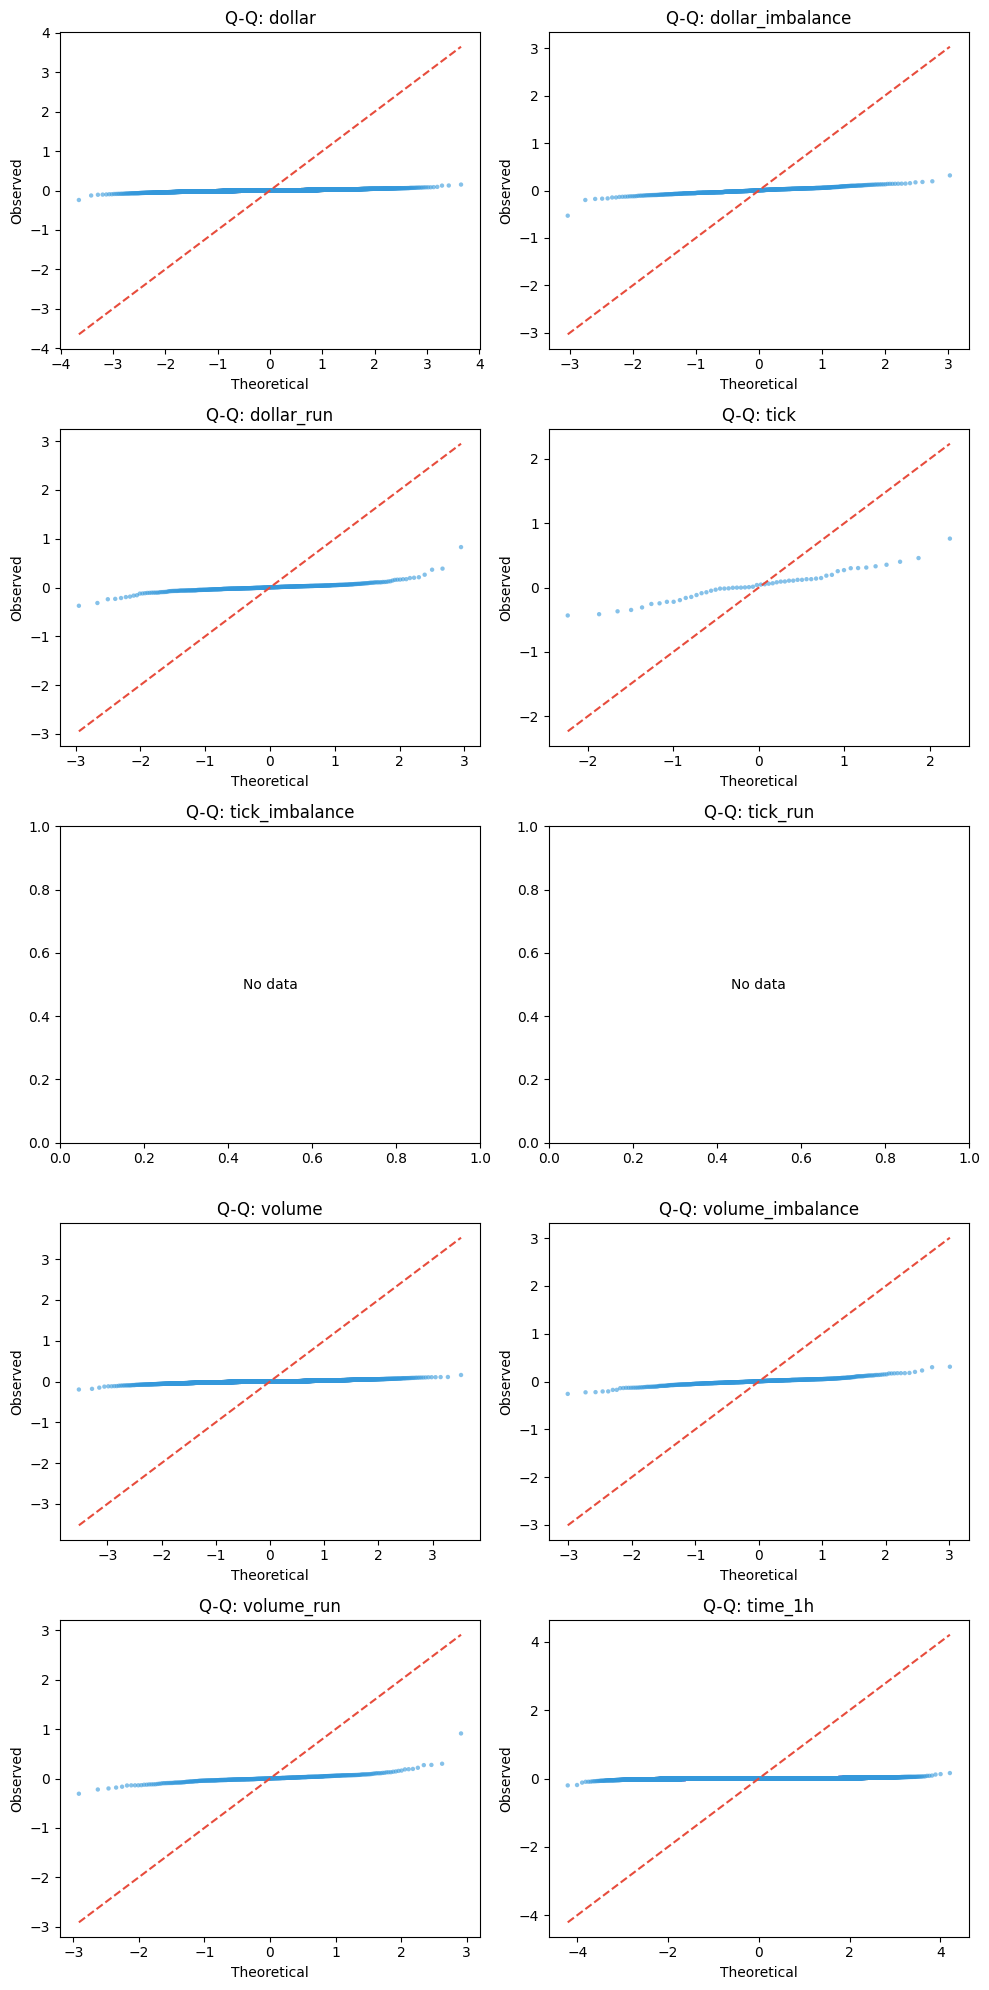

In [16]:
# QQ-plot grid — compare each bar type's returns against normal distribution
qq_data = {}
for bar_type, returns in bar_returns.items():
    theoretical, observed = return_analyzer.compute_qq_data(returns)
    qq_data[bar_type] = (theoretical, observed)

fig = create_qq_grid(qq_data)
plt.show()
plt.close(fig)

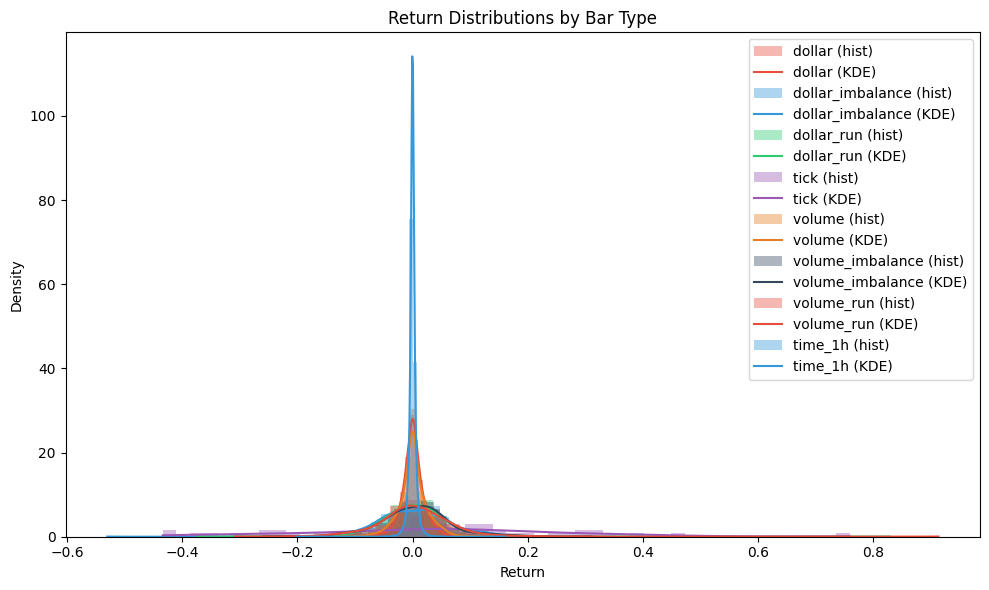

In [17]:
# Return distribution overlay — histograms + KDE per bar type
fig = create_return_distribution(bar_returns)
plt.show()
plt.close(fig)

## 4. Autocorrelation & Serial Dependence

Examine ACF/PACF structure in raw returns (momentum or mean-reversion patterns) and squared returns (volatility clustering / ARCH effects). The Ljung-Box test formally tests for serial correlation. Per Lopez de Prado, information-driven bars should reduce spurious autocorrelation in returns while preserving volatility clustering.

dollar: Ljung-Box Q=47.42, p=0.1957, serial_corr=no
dollar_imbalance: Ljung-Box Q=34.69, p=0.7078, serial_corr=no
dollar_run: Ljung-Box Q=62.10, p=0.0141, serial_corr=YES
tick: Ljung-Box Q=23.04, p=0.6309, serial_corr=no
tick_imbalance: Ljung-Box Q=0.00, p=1.0000, serial_corr=no
tick_run: Ljung-Box Q=0.00, p=1.0000, serial_corr=no
volume: Ljung-Box Q=55.93, p=0.0485, serial_corr=YES
volume_imbalance: Ljung-Box Q=49.15, p=0.1522, serial_corr=no
volume_run: Ljung-Box Q=27.22, p=0.9383, serial_corr=no
time_1h: Ljung-Box Q=218.77, p=0.0000, serial_corr=YES


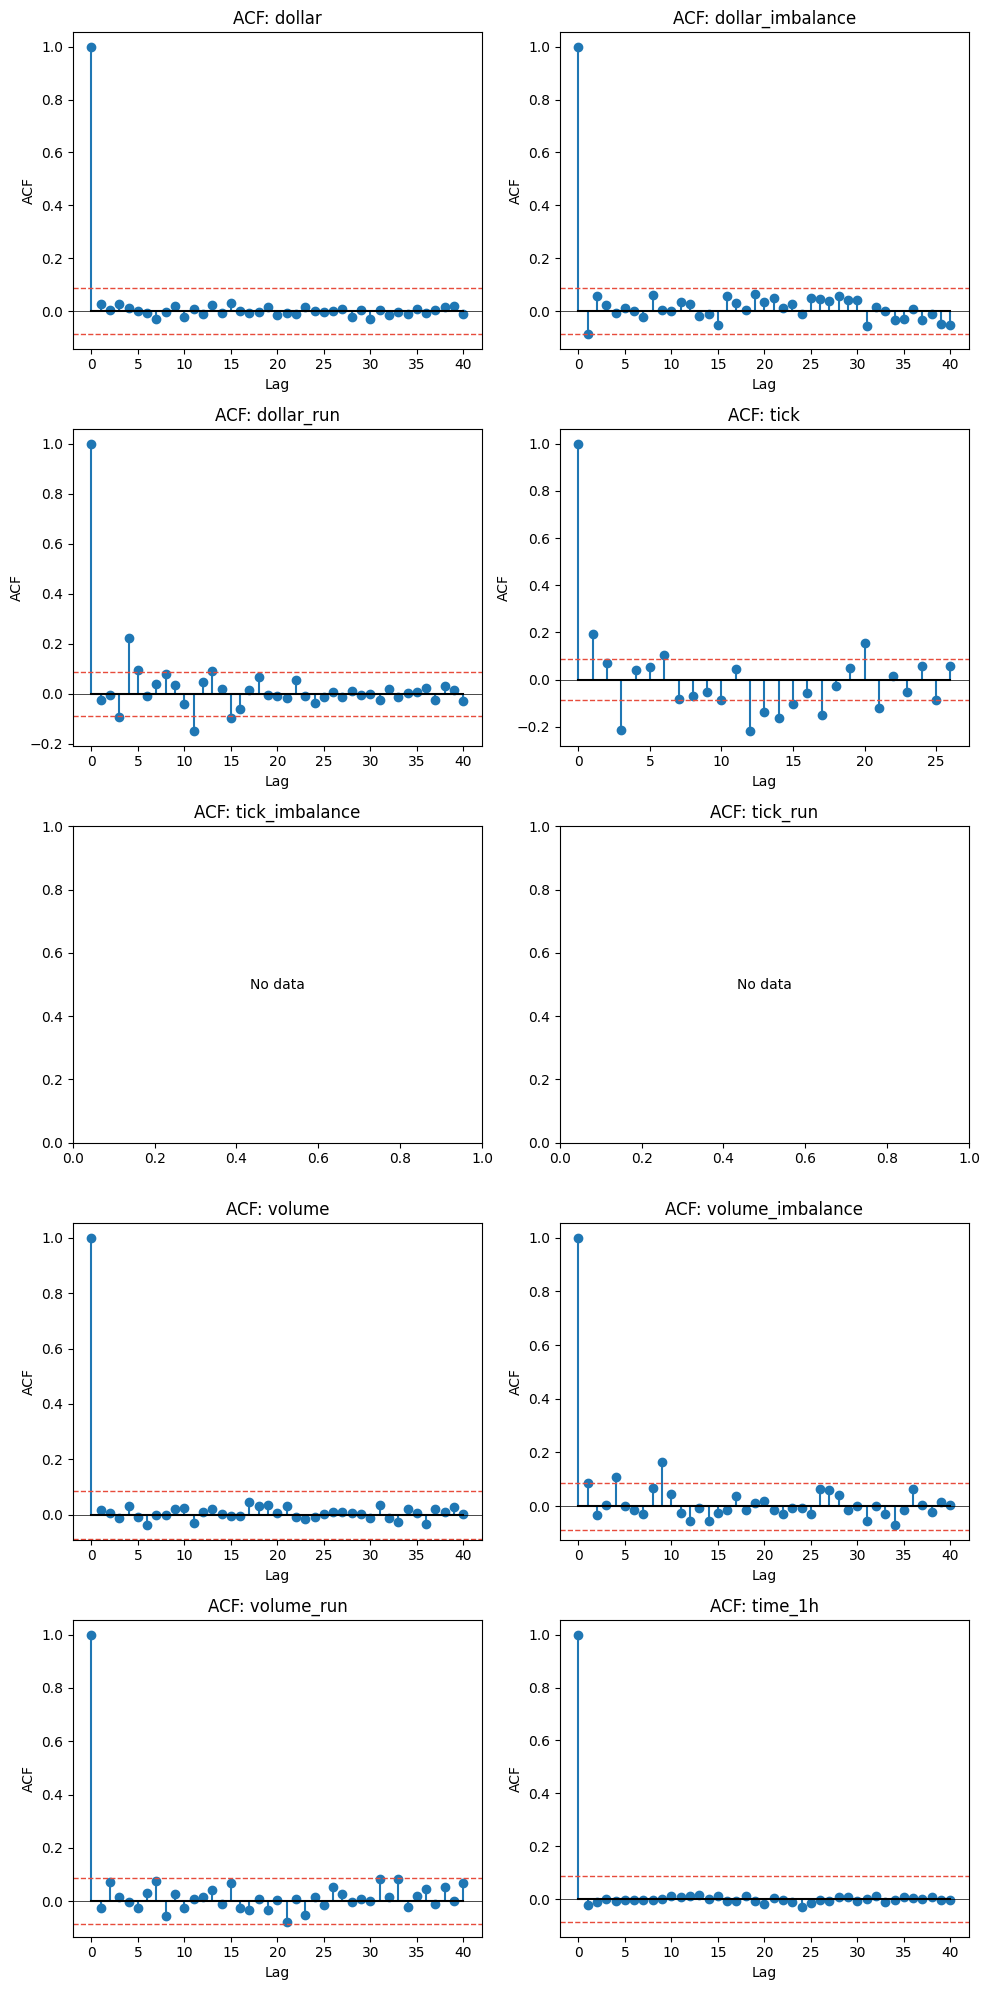

In [18]:
# ACF analysis on raw returns per bar type
acf_results = {}
for bar_type, returns in bar_returns.items():
    result = acf_analyzer.compute_acf_analysis(returns, analysis_asset, bar_type)
    acf_results[bar_type] = result
    print(
        f"{bar_type}: Ljung-Box Q={result.ljung_box_stat:.2f}, "
        f"p={result.ljung_box_pvalue:.4f}, "
        f"serial_corr={'YES' if result.has_serial_correlation else 'no'}"
    )

# ACF comparison grid (matplotlib)
acf_arrays = {bt: r.acf_values for bt, r in acf_results.items()}
fig = create_acf_comparison_grid(acf_arrays)
plt.show()
plt.close(fig)

dollar (r²): Ljung-Box Q=3569.83, p=0.0000, vol_clustering=YES
dollar_imbalance (r²): Ljung-Box Q=99.87, p=0.0000, vol_clustering=YES
dollar_run (r²): Ljung-Box Q=41.38, p=0.4101, vol_clustering=no
tick (r²): Ljung-Box Q=16.46, p=0.9246, vol_clustering=no
tick_imbalance (r²): Ljung-Box Q=0.00, p=1.0000, vol_clustering=no
tick_run (r²): Ljung-Box Q=0.00, p=1.0000, vol_clustering=no
volume (r²): Ljung-Box Q=2600.90, p=0.0000, vol_clustering=YES
volume_imbalance (r²): Ljung-Box Q=572.98, p=0.0000, vol_clustering=YES
volume_run (r²): Ljung-Box Q=0.35, p=1.0000, vol_clustering=no
time_1h (r²): Ljung-Box Q=18395.43, p=0.0000, vol_clustering=YES


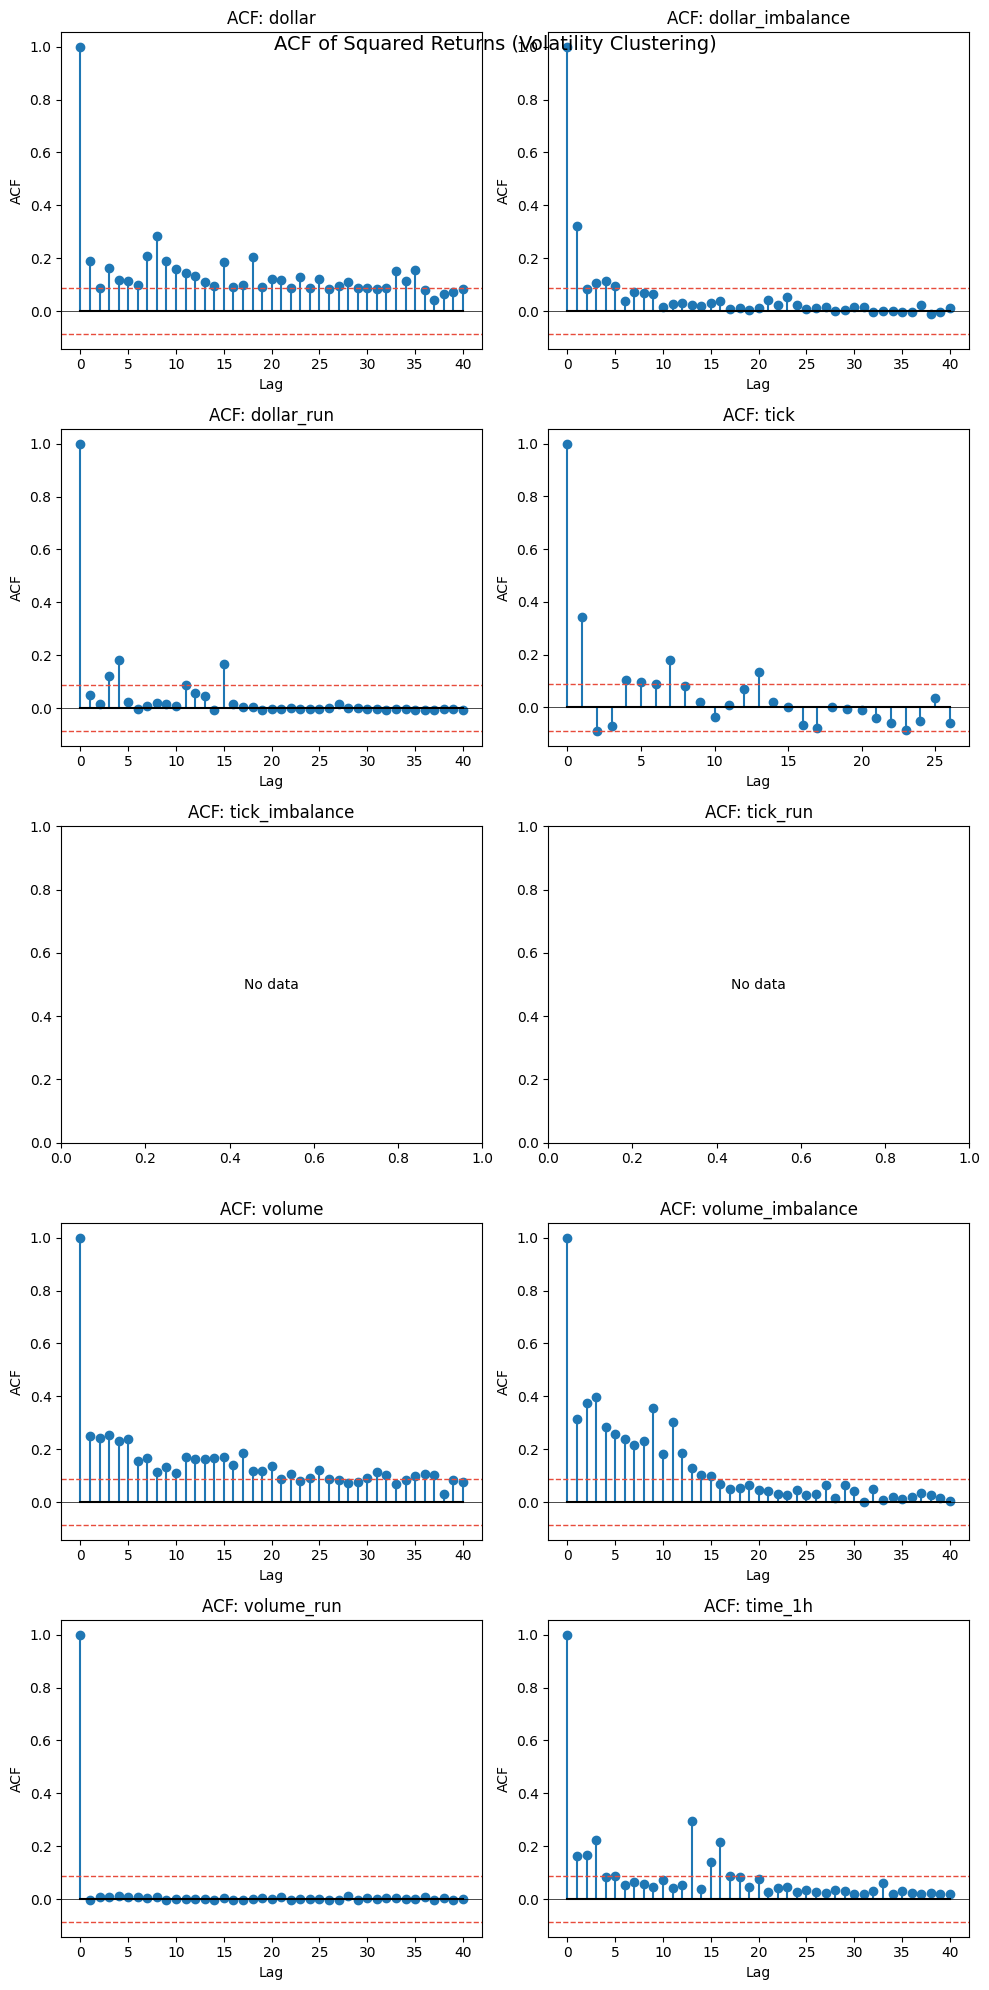

In [19]:
# ACF analysis on SQUARED returns (volatility clustering / ARCH effects)
squared_acf_results = {}
for bar_type, returns in bar_returns.items():
    result = acf_analyzer.compute_squared_acf(returns, analysis_asset, bar_type)
    squared_acf_results[bar_type] = result
    print(
        f"{bar_type} (r²): Ljung-Box Q={result.ljung_box_stat:.2f}, "
        f"p={result.ljung_box_pvalue:.4f}, "
        f"vol_clustering={'YES' if result.has_serial_correlation else 'no'}"
    )

# ACF comparison grid for squared returns
sq_acf_arrays = {bt: r.acf_values for bt, r in squared_acf_results.items()}
fig = create_acf_comparison_grid(sq_acf_arrays)
fig.suptitle("ACF of Squared Returns (Volatility Clustering)", fontsize=14)
plt.show()
plt.close(fig)

In [20]:
# Ljung-Box summary table
ljung_box_rows = []
for bar_type in bar_returns:
    raw = acf_results[bar_type]
    sq = squared_acf_results[bar_type]
    ljung_box_rows.append(
        {
            "bar_type": bar_type,
            "LB_stat_returns": round(raw.ljung_box_stat, 2),
            "LB_pvalue_returns": round(raw.ljung_box_pvalue, 4),
            "serial_corr": raw.has_serial_correlation,
            "LB_stat_squared": round(sq.ljung_box_stat, 2),
            "LB_pvalue_squared": round(sq.ljung_box_pvalue, 4),
            "vol_clustering": sq.has_serial_correlation,
        }
    )

ljung_box_df = pd.DataFrame(ljung_box_rows)
print("Ljung-Box Test Summary (lag=40):")
display(ljung_box_df)

Ljung-Box Test Summary (lag=40):


,bar_type,LB_stat_returns,LB_pvalue_returns,serial_corr,LB_stat_squared,LB_pvalue_squared,vol_clustering
0,dollar,47.420000,0.195700,False,3569.830000,0.000000,True
1,dollar_imbalance,34.690000,0.707800,False,99.870000,0.000000,True
2,dollar_run,62.100000,0.014100,True,41.380000,0.410100,False
3,tick,23.040000,0.630900,False,16.460000,0.924600,False
4,tick_imbalance,0.000000,1.000000,False,0.000000,1.000000,False
5,tick_run,0.000000,1.000000,False,0.000000,1.000000,False
6,volume,55.930000,0.048500,True,2600.900000,0.000000,True
7,volume_imbalance,49.150000,0.152200,False,572.980000,0.000000,True
8,volume_run,27.220000,0.938300,False,0.350000,1.000000,False
9,time_1h,218.770000,0.000000,True,18395.430000,0.000000,True


## 5. Conclusions & Go/No-Go Decisions

Summary comparison table and answers to the four research checkpoint questions.

In [21]:
# Summary comparison table across bar types
summary_rows = []
for bar_type in bar_returns:
    stat = next(s for s in all_return_stats if s.bar_type == bar_type)
    acf_r = acf_results[bar_type]
    acf_sq = squared_acf_results[bar_type]
    summary_rows.append(
        {
            "bar_type": bar_type,
            "n_returns": stat.count,
            "mean": round(stat.mean, 6),
            "std": round(stat.std, 6),
            "skewness": round(stat.skewness, 3),
            "excess_kurtosis": round(stat.kurtosis, 3),
            "JB_pvalue": round(stat.jarque_bera_pvalue, 4),
            "is_normal": stat.is_normal,
            "serial_corr": acf_r.has_serial_correlation,
            "vol_clustering": acf_sq.has_serial_correlation,
        }
    )

summary_df = pd.DataFrame(summary_rows)
print("=== RC1 Summary Comparison Table ===\n")
display(summary_df)

=== RC1 Summary Comparison Table ===



,bar_type,n_returns,mean,std,skewness,excess_kurtosis,JB_pvalue,is_normal,serial_corr,vol_clustering
0,dollar,5286,0.000428,0.020459,-0.359000,6.717000,0.000000,False,False,True
1,dollar_imbalance,568,0.003790,0.065209,-0.733000,8.279000,0.000000,False,False,True
2,dollar_run,434,0.004906,0.078977,2.661000,30.515000,0.000000,False,True,False
3,tick,54,0.035706,0.230587,0.283000,0.711000,0.395000,True,False,False
4,tick_imbalance,1,0.870738,0.000000,0.000000,0.000000,1.000000,True,False,False
5,tick_run,0,0.000000,0.000000,0.000000,0.000000,1.000000,True,False,False
6,volume,3263,0.000712,0.026559,-0.275000,4.114000,0.000000,False,True,True
7,volume_imbalance,529,0.004177,0.065334,0.166000,2.856000,0.000000,False,False,True
8,volume_run,388,0.005637,0.080217,3.822000,42.614000,0.000000,False,False,False
9,time_1h,54277,0.000042,0.006686,-0.941000,53.314000,0.000000,False,True,True


### Q1: Is the data quality sufficient for modelling?

**Criteria:** Coverage >= 95% for selected assets, no gaps exceeding 48 hours, at least 2 years of hourly data.

**Decision:** _Fill in after running the notebook with real data._

---

### Q2: Do alternative bars (dollar, imbalance, run) improve distributional properties over time bars?

**Criteria:** Lower excess kurtosis, reduced skewness, closer to normality (higher JB p-value).

**Decision:** _Fill in after running the notebook with real data._

---

### Q3: Do information-driven bars reduce serial correlation in returns?

**Criteria:** Ljung-Box p-value > 0.05 for raw returns (no spurious autocorrelation), while squared returns still show clustering (ARCH effects present — a sign the bar preserves meaningful volatility structure).

**Decision:** _Fill in after running the notebook with real data._

---

### Q4: Which bar types should proceed to Phase 4 (feature engineering)?

**Recommendation:** Select bar types that:
1. Have sufficient sample size (>= 1000 bars)
2. Show reduced serial correlation vs time bars
3. Preserve volatility clustering (useful signal)
4. Have reasonable duration variability (CV not extreme)

**Selected bar types for Phase 4:** _Fill in after running the notebook with real data._

In [22]:
# Clean up — dispose database connection
cm.dispose()
print("Database connection closed.")

2026-03-30 00:09:12.515 | INFO     | src.app.system.database.connection:dispose:95 - DuckDB engine disposed


Database connection closed.
